### Overblik over datasættet

In [1]:
import numpy as np
import pandas as pd

In [4]:
df = pd.read_csv("panel2_balanced_with_fertility.csv")

In [5]:
print(df.shape)
print(df.columns)
print(df.head())

(950, 11)
Index(['country', 'code', 'year', 'internet_use', 'odr', 'rd', 'schooling',
       'gdppc', 'log_gdp_pc', 'log_internet_use', 'fertility'],
      dtype='object')
     country code  year  internet_use        odr       rd  schooling  \
0  Argentina  ARG  2002       10.8821  15.660251  0.38886   9.395000   
1  Argentina  ARG  2003       11.9137  15.697126  0.41013   9.920000   
2  Argentina  ARG  2004       16.0367  15.728183  0.40376  10.010000   
3  Argentina  ARG  2005       17.7206  15.785692  0.42074  10.099999   
4  Argentina  ARG  2006       20.9272  15.861772  0.45216  10.190000   

       gdppc  log_gdp_pc  log_internet_use  fertility  
0  18571.701    9.829394          2.387119      2.493  
1  20005.139    9.903744          2.477689      2.451  
2  21591.450    9.980053          2.774880      2.430  
3  23262.408   10.054594          2.874728      2.426  
4  24877.250   10.121709          3.041050      2.400  


In [6]:
print("Antal lande:", df["code"].nunique())
print("Antal år:", df["year"].nunique())

Antal lande: 50
Antal år: 19


In [7]:
years_per_country = df.groupby("code")["year"].nunique().reset_index()
years_per_country = years_per_country.rename(columns={"year": "n_years"})

print(years_per_country.sort_values("n_years"))

   code  n_years
0   ARG       19
27  KGZ       19
28  KOR       19
29  KWT       19
30  LTU       19
31  LVA       19
32  MEX       19
33  MKD       19
34  MLT       19
35  NLD       19
36  NOR       19
37  PAN       19
38  POL       19
39  PRT       19
40  ROU       19
41  RUS       19
42  SGP       19
43  SVK       19
44  SVN       19
45  TTO       19
46  TUR       19
47  UKR       19
26  KAZ       19
25  JPN       19
24  ITA       19
23  ISR       19
1   ARM       19
2   AUT       19
3   BEL       19
4   BGR       19
5   BRA       19
6   CAN       19
7   CHN       19
8   COL       19
9   CYP       19
10  CZE       19
48  USA       19
11  DEU       19
13  ESP       19
14  EST       19
15  FIN       19
16  FRA       19
17  GBR       19
18  HKG       19
19  HRV       19
20  HUN       19
21  IND       19
22  IRL       19
12  DNK       19
49  UZB       19


In [22]:
missing = df.isna().mean().sort_values(ascending=False)
print(missing)

country             0.0
code                0.0
year                0.0
internet_use        0.0
odr                 0.0
rd                  0.0
schooling           0.0
gdppc               0.0
log_gdp_pc          0.0
log_internet_use    0.0
fertility           0.0
dtype: float64


In [23]:
print(df.describe().round(2))

          year  internet_use     odr      rd  schooling      gdppc  \
count   950.00        950.00  950.00  950.00     950.00     950.00   
mean   2011.00         58.45   20.16    1.31      10.92   37910.40   
std       5.48         26.04    8.26    1.05       2.02   20639.08   
min    2002.00          1.08    2.30    0.03       4.30    3250.70   
25%    2006.00         39.93   13.17    0.47      10.19   21855.79   
50%    2011.00         64.75   20.96    1.05      11.35   35814.35   
75%    2016.00         79.44   26.20    1.97      12.38   51625.71   
max    2020.00         99.60   48.98    5.80      14.26  120114.13   

       log_gdp_pc  log_internet_use  fertility  
count      950.00            950.00     950.00  
mean        10.36              3.87       1.73  
std          0.68              0.78       0.48  
min          8.09              0.08       0.81  
25%          9.99              3.69       1.39  
50%         10.49              4.17       1.61  
75%         10.85         

In [24]:
for col in ["internet_use", "odr", "gdppc", "fertility"]:
    print(col)
    print(df.groupby("code")[col].std().mean())

internet_use
18.20558216343804
odr
2.3427273774511495
gdppc
4220.709666017432
fertility
0.1291317714636349


In [25]:
n_years = df["year"].nunique()

balanced = years_per_country["n_years"].eq(n_years).all()

print("Er panelet balanceret?", balanced)

Er panelet balanceret? True


In [26]:
print(df[["internet_use", "odr", "gdppc", "fertility", "rd"]].corr())

              internet_use       odr     gdppc  fertility        rd
internet_use      1.000000  0.523356  0.648699  -0.302269  0.514528
odr               0.523356  1.000000  0.337318  -0.520544  0.461435
gdppc             0.648699  0.337318  1.000000  -0.309909  0.515666
fertility        -0.302269 -0.520544 -0.309909   1.000000 -0.140933
rd                0.514528  0.461435  0.515666  -0.140933  1.000000


In [27]:
df_year = df.groupby("year").mean(numeric_only=True).reset_index()

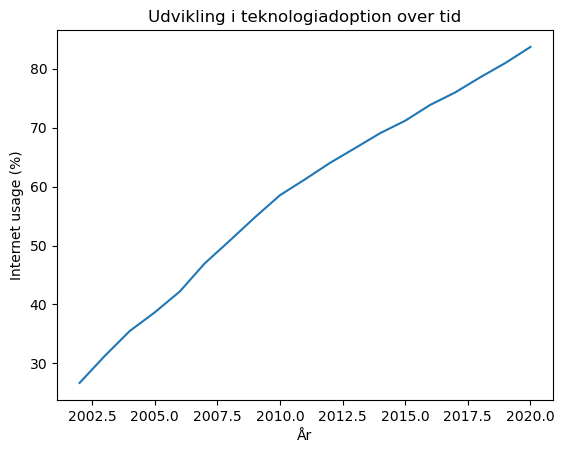

In [28]:
import matplotlib.pyplot as plt

plt.plot(df_year["year"], df_year["internet_use"])
plt.xlabel("År")
plt.ylabel("Internet usage (%)")
plt.title("Udvikling i teknologiadoption over tid")
plt.show()

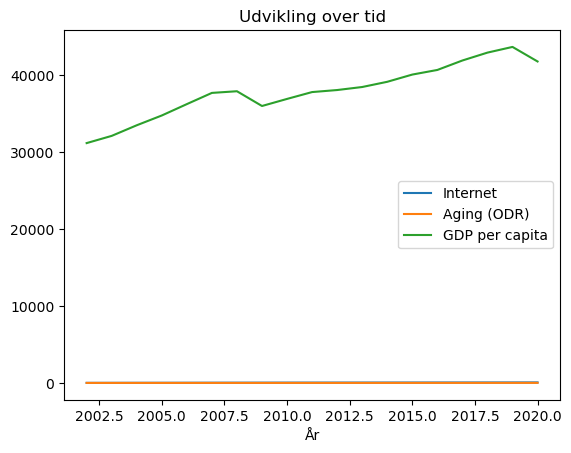

In [18]:
plt.plot(df_year["year"], df_year["internet_use"], label="Internet")
plt.plot(df_year["year"], df_year["odr"], label="Aging (ODR)")
plt.plot(df_year["year"], df_year["gdppc"], label="GDP per capita")

plt.legend()
plt.xlabel("År")
plt.title("Udvikling over tid")
plt.show()

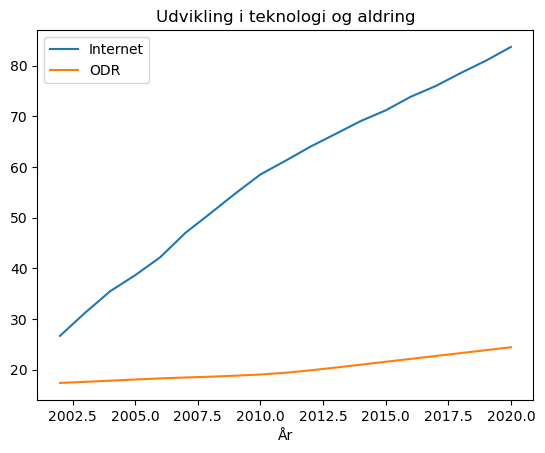

In [19]:
plt.plot(df_year["year"], df_year["internet_use"], label="Internet")
plt.plot(df_year["year"], df_year["odr"], label="ODR")

plt.legend()
plt.xlabel("År")
plt.title("Udvikling i teknologi og aldring")
plt.show()

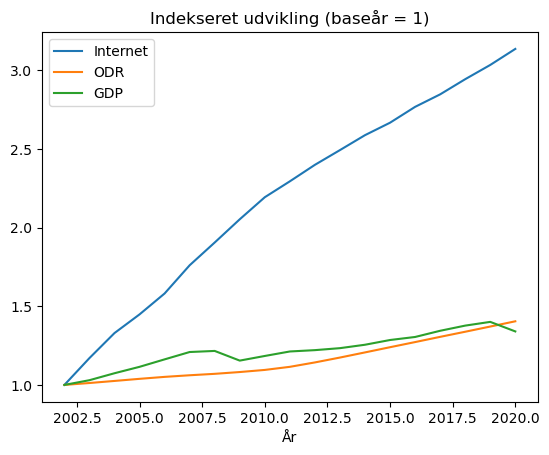

In [20]:
df_norm = df_year.copy()

for col in ["internet_use", "odr", "gdppc"]:
    df_norm[col] = df_norm[col] / df_norm[col].iloc[0]

plt.plot(df_norm["year"], df_norm["internet_use"], label="Internet")
plt.plot(df_norm["year"], df_norm["odr"], label="ODR")
plt.plot(df_norm["year"], df_norm["gdppc"], label="GDP")

plt.legend()
plt.title("Indekseret udvikling (baseår = 1)")
plt.xlabel("År")
plt.show()

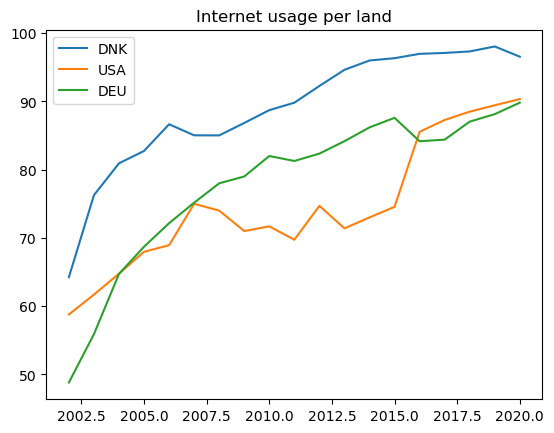

In [21]:
for country in ["DNK", "USA", "DEU"]:
    temp = df[df["code"] == country]
    plt.plot(temp["year"], temp["internet_use"], label=country)

plt.legend()
plt.title("Internet usage per land")
plt.show()